<a href="https://colab.research.google.com/github/kittiporntum1-cell/ADALL_github/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
# Example: Replace this with the raw URL of your GitHub file
github_raw_url = 'https://raw.githubusercontent.com/kittiporntum1-cell/ADALL_github/refs/heads/main/laptop_prices_2024_sgd_TL.csv'
try:
  df = pd.read_csv(github_raw_url)
  print("Successfully loaded data from GitHub!")
  display(df.head())
except Exception as e:
  print(f"Error loading data: {e}")
  print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")

Successfully loaded data from GitHub!


,Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,3.27,2413.36,5,144.80
1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,5.03,1773.75,5,124.16
2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,4.41,1634.07,5,98.04
3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,2.16,2362.59,5,118.13
4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,6.93,2218.55,5,155.30


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Model             1000 non-null   object 
 2   CPU               1000 non-null   object 
 3   GPU               1000 non-null   object 
 4   RAM_GB            1000 non-null   int64  
 5   Storage_Type      1000 non-null   object 
 6   Storage_GB        1000 non-null   int64  
 7   Touchscreen       1000 non-null   bool   
 8   Weight_kg         1000 non-null   float64
 9   Screen_Size_inch  1000 non-null   float64
 10  Discount_percent  1000 non-null   float64
 11  Price_SGD         1000 non-null   float64
 12  Brand_Discount    1000 non-null   int64  
 13  Member_Discount   1000 non-null   float64
dtypes: bool(1), float64(5), int64(3), object(5)
memory usage: 102.7+ KB


In [5]:
# Convert the first few rows to a string to send to OpenAI (Brief information need to give to Open AI : Practical test: Payload)
data_preview = df.head(10).to_csv(index=False)
print(data_preview)

response = client.responses.create(
model="gpt-5-mini",
instructions="You are an expert data scientist with extensive knowledge of predictive analysis and linear regression.",  # Instruction: context, problem statement and what you want to achieve, can be give here
input=f"Dataset: Laptop price Prediction (1000 samples, 14 features, target is Price_SGD)\nHere are the first 10 rows of the dataset:\n{data_preview}]",
) #Input context that relavant to the data set, give to OpenAI
print(response.output_text)

Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,3.27,2413.36,5,144.8
Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,5.03,1773.75,5,124.16
Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,4.41,1634.07,5,98.04
Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,2.16,2362.59,5,118.13
Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,6.93,2218.55,5,155.3
Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4080,32,SSD,256,False,3.34,17.3,8.94,2224.12,5,155.69
Acer,TravelMate P6,Intel i9-14900HK,NVIDIA RTX 4080,128,SSD,1024,True,1.11,13.3,11.72,3016.36,5,211.15
Acer,Predator Helios 300,Intel Core Ultra 9 15700H,NVIDIA RTX 4070,16,SSD,2048,True,1.29,13.3,8.84,2579.29,5,180.55
Acer,Swift 3,Intel i5-14500H,NVIDIA

Usually XML and Json will be better for payload (Better than CSV)

In [2]:
from google.colab import userdata
from openai import OpenAI


# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')


client = OpenAI(
# This is the default and can be omitted
api_key=api_key,

)

response = client.responses.create(
    model="gpt-5-mini",
    instructions="You are a data analyst expert who uses Python.",
    input="What is Exploratory Data Analysis?"
)

print(response.output_text)


Exploratory Data Analysis (EDA) is the process of investigating and summarizing a dataset to understand its structure, patterns, relationships, anomalies, and quality before formal modeling. It’s an iterative, visual and statistical approach to develop intuition, generate hypotheses, and guide subsequent data cleaning and modeling.

Key goals
- Understand data types, shape and structure
- Summarize distributions of variables and detect outliers
- Identify missing values and data quality issues
- Discover relationships and correlations between variables
- Generate hypotheses and inform feature engineering and modeling choices

Common steps in an EDA workflow
1. Acquire and inspect data: load files, check dimensions and column types.
2. Data summary: compute descriptive statistics (mean, median, std, quartiles).
3. Missing-value and uniqueness analysis: percentages, patterns.
4. Univariate analysis: histograms, density plots, bar charts for single variables.
5. Bivariate analysis: scatte

In [ ]:
from google.colab import userdata
from openai import OpenAI

#Load key from Google Colabsecrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    #This is the default and can be omitted
    api_key=api_key,
)

response = client.responses.create(
    model="gpt-5-mini",
    instructions ="You are a data analyst expert who uses Python.",
    input="What is Exploratory Data Analysis?",
)

In [ ]:
print ("Descriptive statistics for numerical columns:")
df.describe()

Descriptive statistics for numerical columns:


,RAM_GB,Storage_GB,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000
mean,53.128000,1505.024000,2.036560,15.645700,7.538230,2277.796410,6.7680,135.810660
std,44.413288,1380.203919,0.746477,1.759846,4.334012,616.496246,2.6346,41.344593
min,8.000000,256.000000,1.000000,13.300000,0.000000,995.770000,3.0000,50.740000
25%,16.000000,512.000000,1.340000,14.000000,3.815000,1776.212500,5.0000,103.435000
50%,32.000000,1024.000000,1.970000,15.600000,7.480000,2257.765000,7.0000,131.095000
75%,64.000000,2048.000000,2.680000,17.300000,11.225000,2711.680000,10.0000,163.052500
max,128.000000,4096.000000,3.500000,18.400000,15.000000,4156.500000,10.0000,281.340000


### 5. Advanced Descriptive Statistics

#### Numerical Features: Skewness and Kurtosis

In [ ]:
print("Skewness for numerical features:")
print(df[numerical_cols].skew())

print("\nKurtosis for numerical features:")
print(df[numerical_cols].kurt())

Skewness for numerical features:
RAM_GB              0.746462
Storage_GB          0.992171
Weight_kg           0.272414
Screen_Size_inch    0.111150
Discount_percent   -0.006877
Price_SGD           0.281510
Brand_Discount      0.071668
Member_Discount     0.503652
dtype: float64

Kurtosis for numerical features:
RAM_GB             -0.914989
Storage_GB         -0.467095
Weight_kg          -1.268922
Screen_Size_inch   -1.268281
Discount_percent   -1.168161
Price_SGD          -0.555200
Brand_Discount     -1.464838
Member_Discount    -0.155901
dtype: float64


#### Categorical Features: Visualizing Distributions

/tmp/ipykernel_554/391665229.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


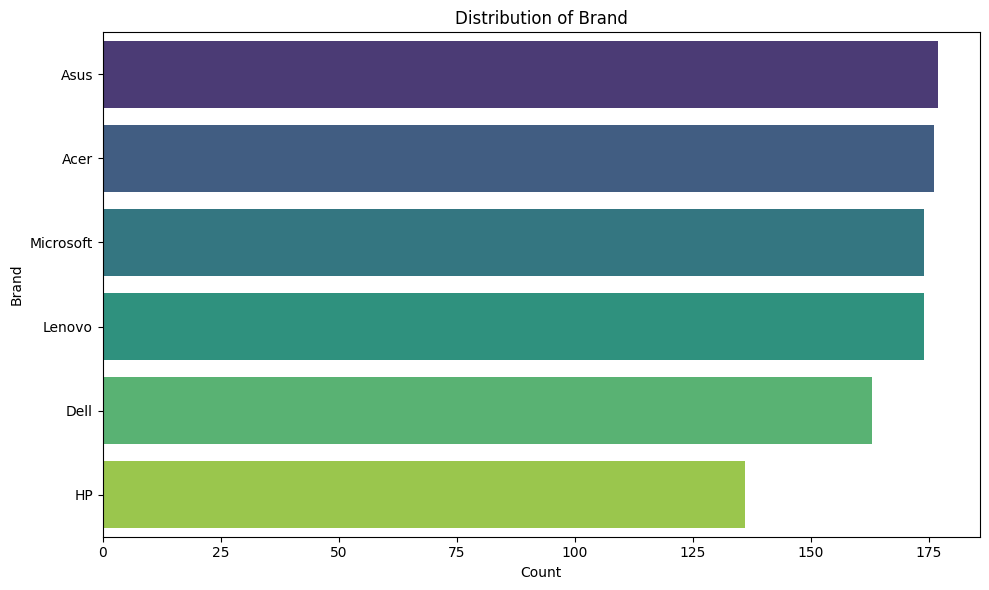

/tmp/ipykernel_554/391665229.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


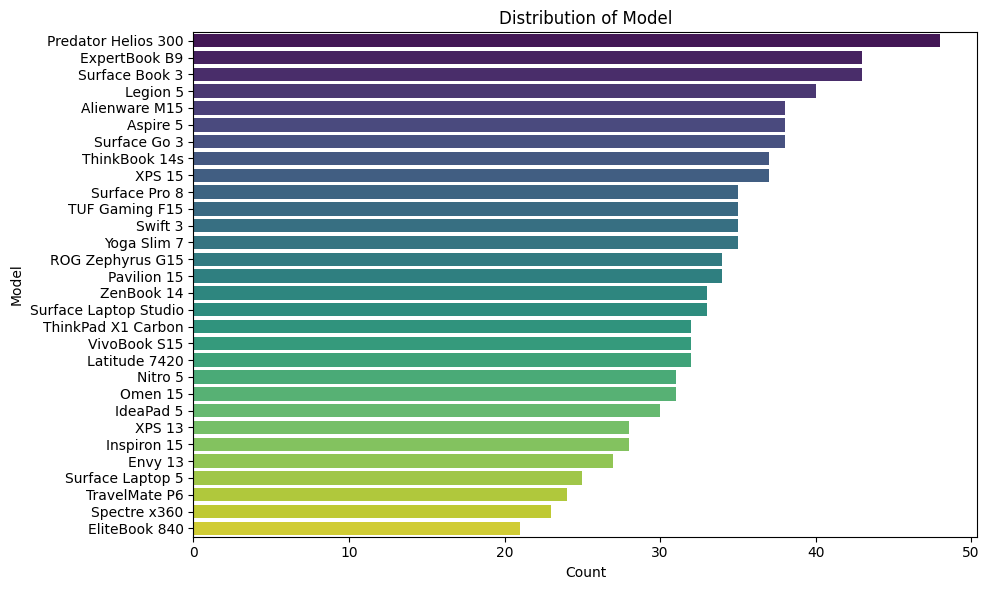

/tmp/ipykernel_554/391665229.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


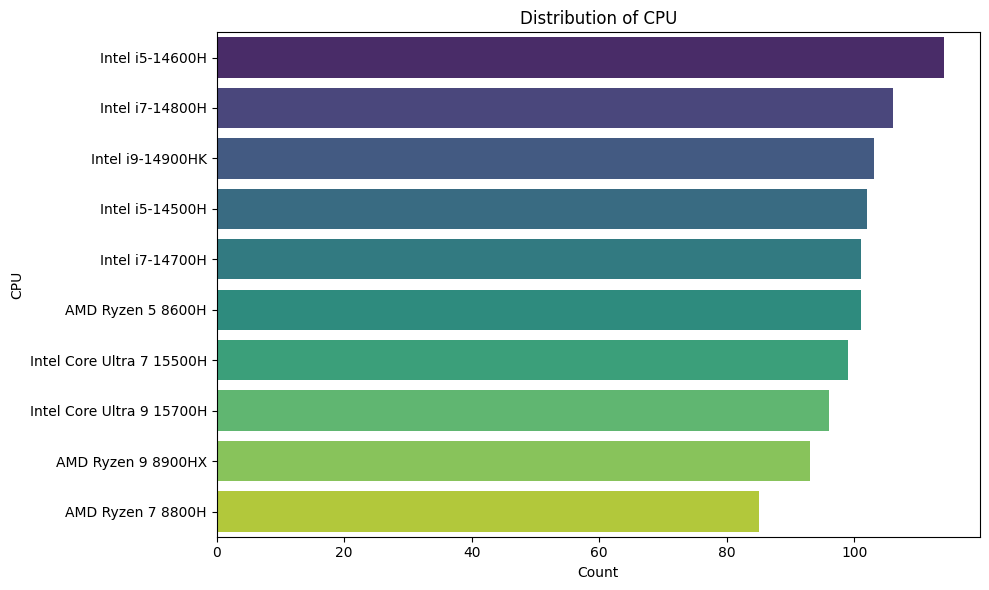

/tmp/ipykernel_554/391665229.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


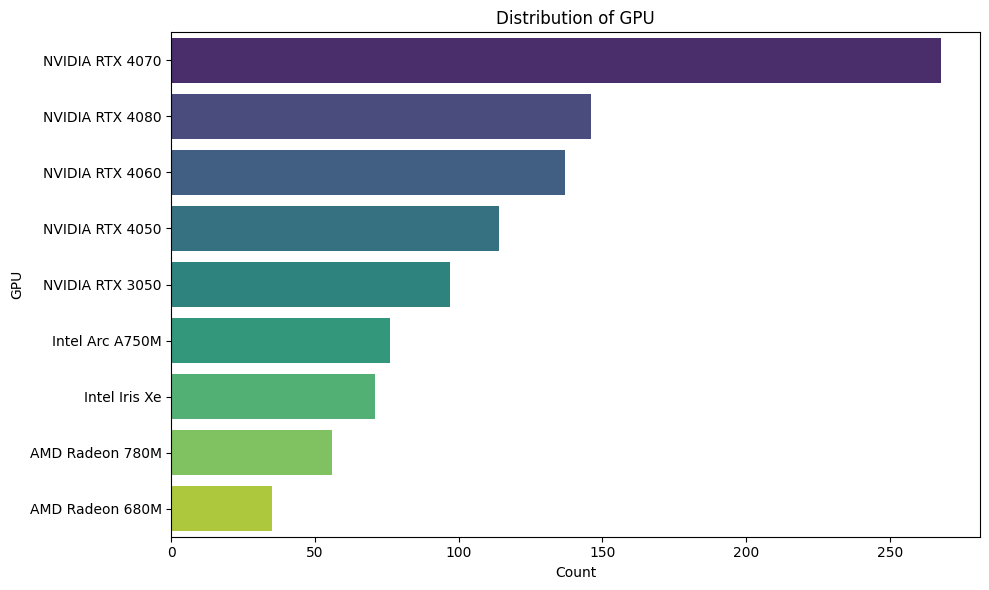

/tmp/ipykernel_554/391665229.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


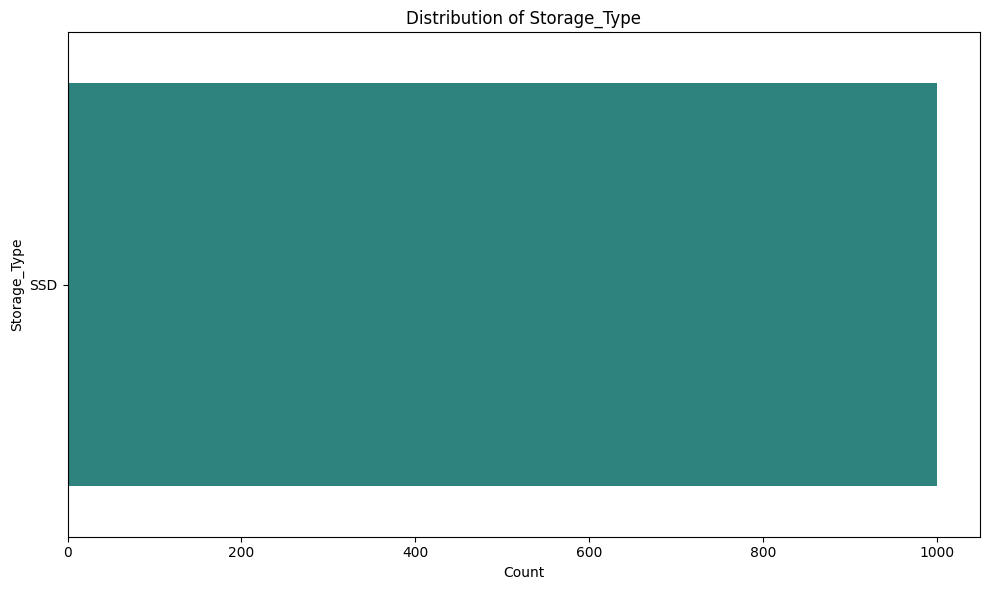

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 1. Check for Missing Values

Missing values in each column:
Series([], dtype: int64)


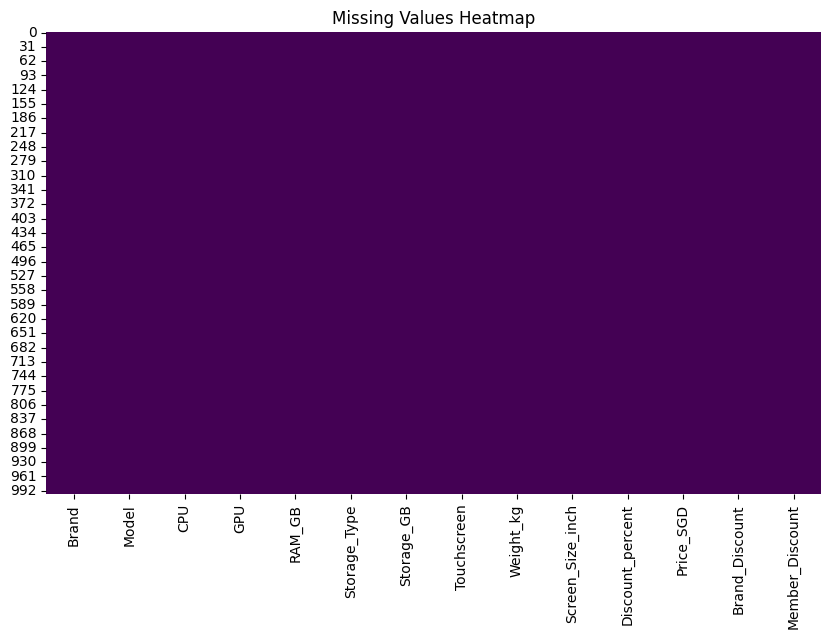

In [ ]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

import matplotlib.pyplot as plt
import seaborn as sns

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### 2. Check for Duplicate Rows

In [ ]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("\nSuggestion: Consider removing duplicate rows if they represent exact copies of observations and are not intentional.")
    # Example of how to drop duplicates (uncomment if needed)
    # df.drop_duplicates(inplace=True)
    # print(f"Number of rows after dropping duplicates: {len(df)}")

Number of duplicate rows: 0


### 3. Analyze Categorical Features

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Top 10 unique values and their counts:")
    print(df[col].value_counts().head(10))

    if df[col].nunique() > 50: # Arbitrary threshold for high cardinality
        print(f"Suggestion: Column '{col}' has high cardinality. Consider grouping similar categories or using encoding techniques like target encoding, or dimensionality reduction.")
    elif df[col].nunique() < df.shape[0] * 0.01 and df[col].nunique() > 1: # Low cardinality but more than one unique value
        print(f"Suggestion: Column '{col}' seems to be a good candidate for one-hot encoding or label encoding.")

    # Check for inconsistent capitalization or spelling (simple check)
    if df[col].apply(lambda x: isinstance(x, str) and x.lower() != x.upper()).any(): # Check if there's any case variation
        unique_lower = df[col].str.lower().nunique()
        if unique_lower < df[col].nunique():
            print(f"Potential Data Issue: Column '{col}' might have inconsistent capitalization. For example, 'Apple' and 'apple' would be counted as two unique values but mean the same thing. Suggestion: Standardize to a consistent case (e.g., `df['{col}'].str.lower()`).")


--- Column: Brand ---
Number of unique values: 6
Top 10 unique values and their counts:
Brand
Asus         177
Acer         176
Microsoft    174
Lenovo       174
Dell         163
HP           136
Name: count, dtype: int64
Suggestion: Column 'Brand' seems to be a good candidate for one-hot encoding or label encoding.

--- Column: Model ---
Number of unique values: 30
Top 10 unique values and their counts:
Model
Predator Helios 300    48
ExpertBook B9          43
Surface Book 3         43
Legion 5               40
Alienware M15          38
Aspire 5               38
Surface Go 3           38
ThinkBook 14s          37
XPS 15                 37
Surface Pro 8          35
Name: count, dtype: int64

--- Column: CPU ---
Number of unique values: 10
Top 10 unique values and their counts:
CPU
Intel i5-14600H              114
Intel i7-14800H              106
Intel i9-14900HK             103
Intel i5-14500H              102
Intel i7-14700H              101
AMD Ryzen 5 8600H            101
Intel Cor

### 4. Analyze Numerical Features


--- Column: RAM_GB ---


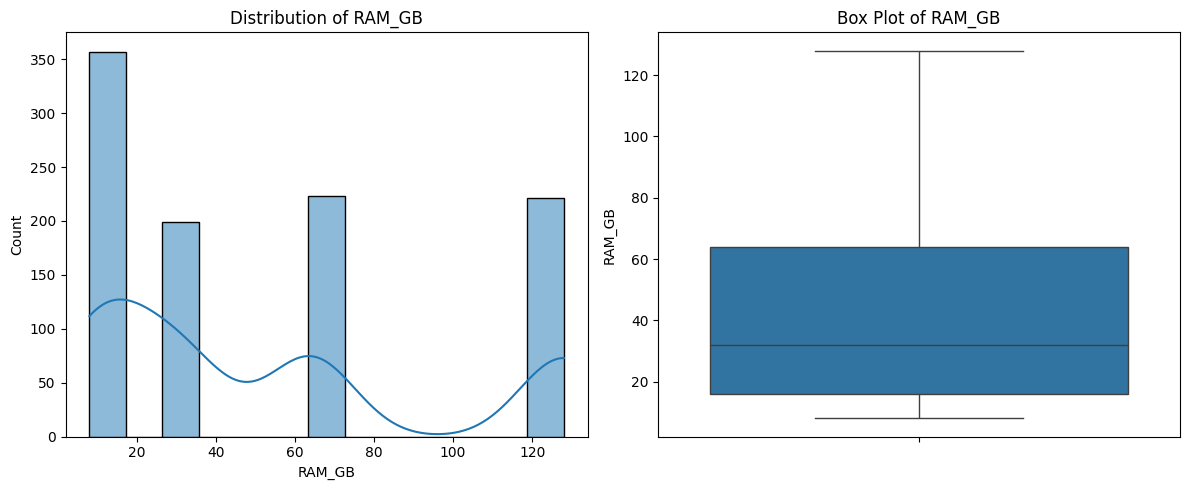


--- Column: Storage_GB ---


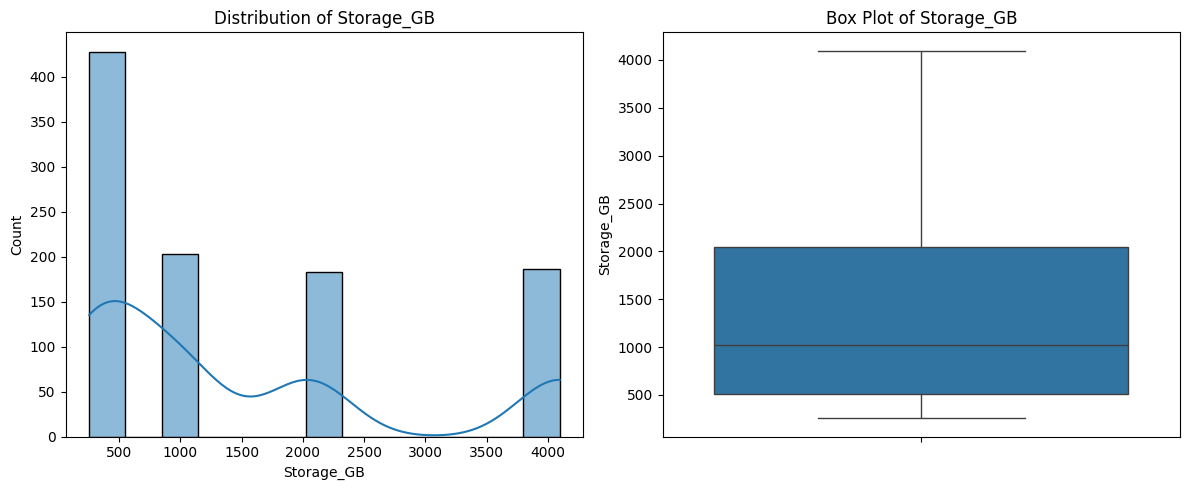


--- Column: Weight_kg ---


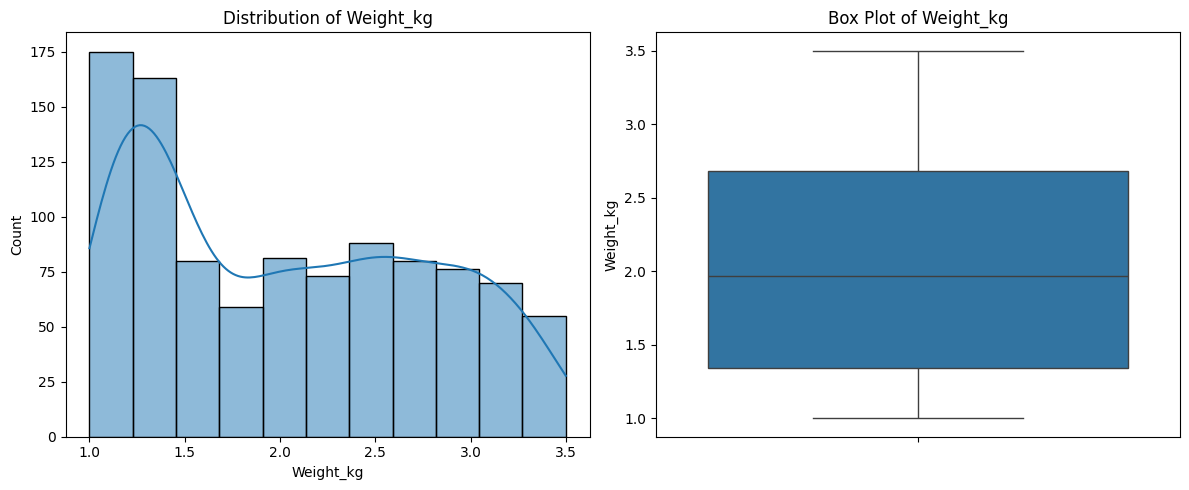


--- Column: Screen_Size_inch ---


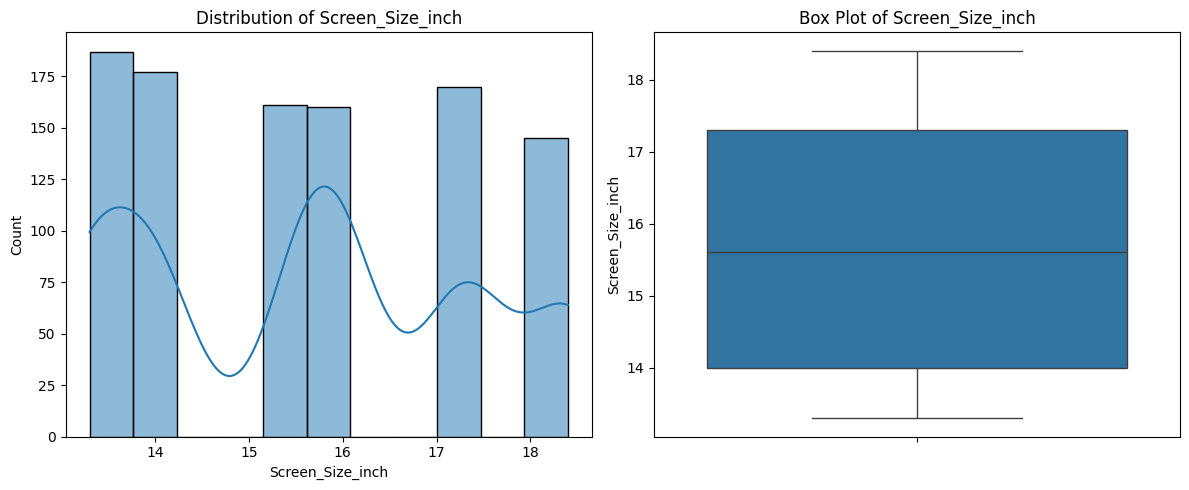


--- Column: Discount_percent ---


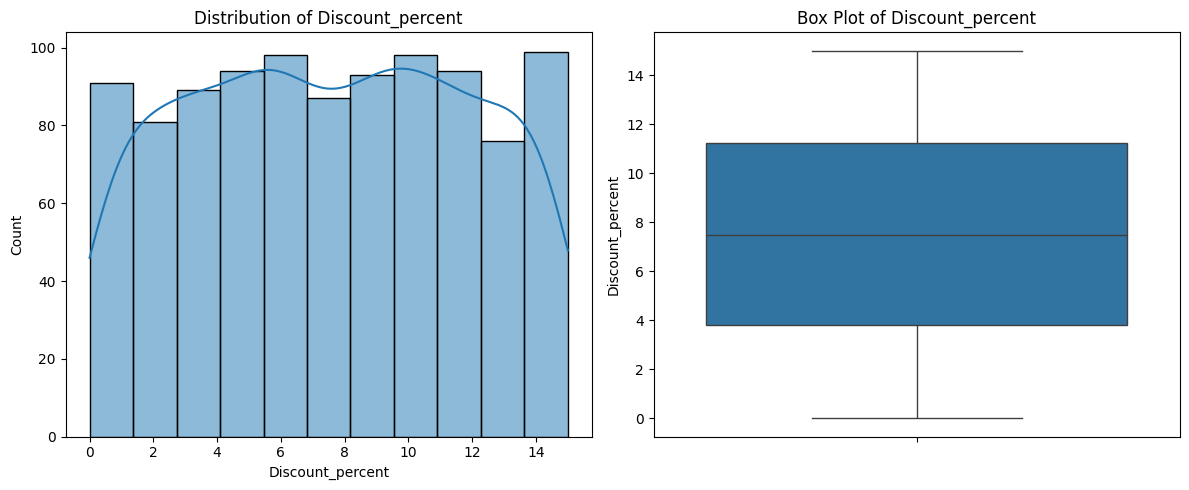


--- Column: Price_SGD ---


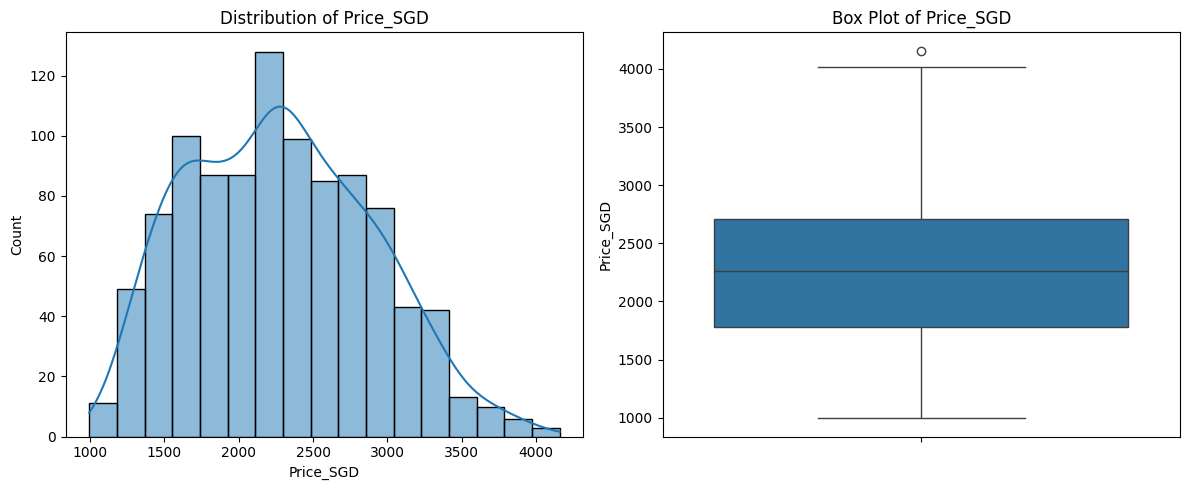

Potential Data Issue: Column 'Price_SGD' has 1 outliers. Suggestion: Investigate these outliers. Depending on the context, you might cap them, remove them, or transform the data.

--- Column: Brand_Discount ---


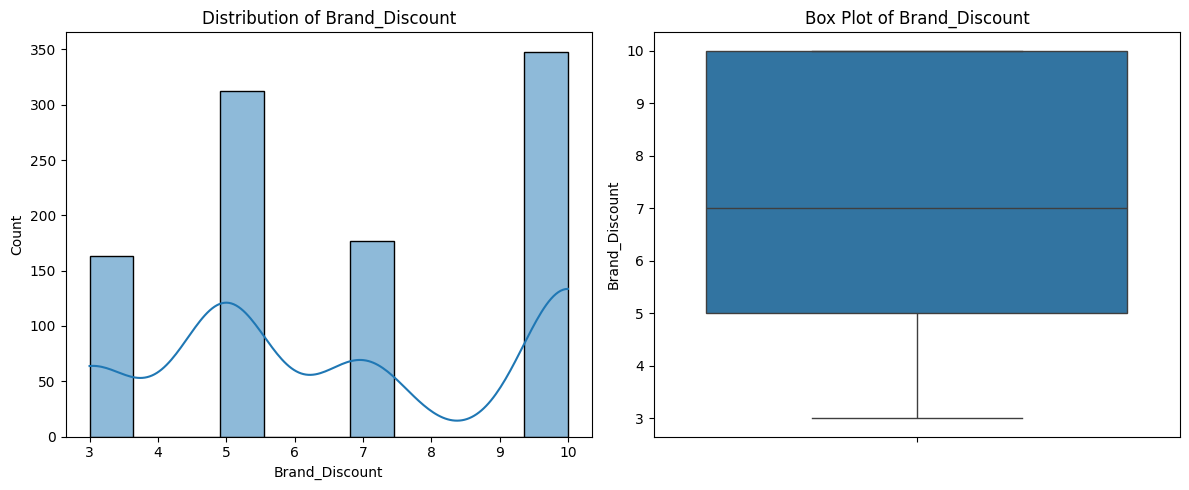


--- Column: Member_Discount ---


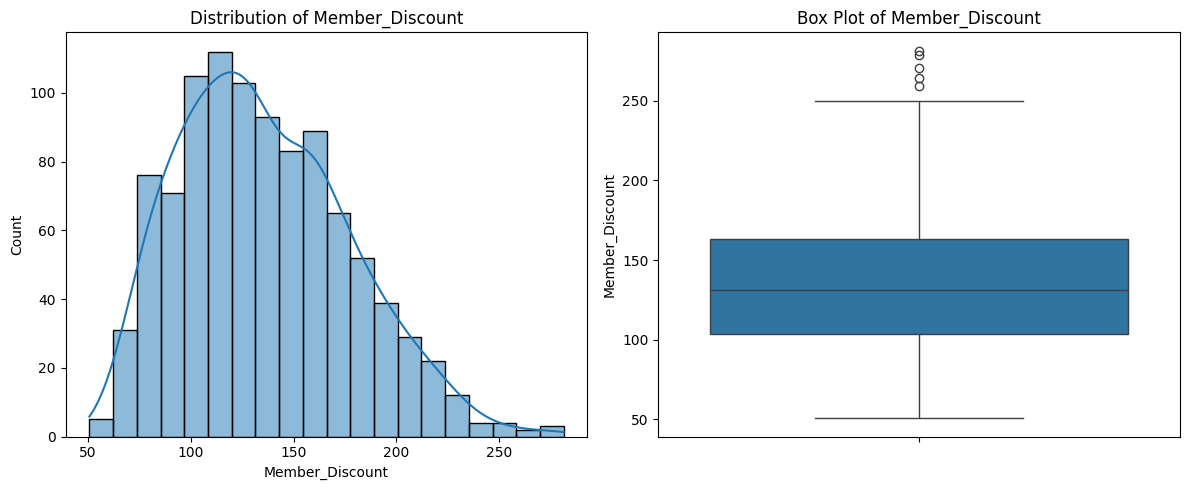

Potential Data Issue: Column 'Member_Discount' has 5 outliers. Suggestion: Investigate these outliers. Depending on the context, you might cap them, remove them, or transform the data.


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    print(f"\n--- Column: {col} ---")
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')

    plt.tight_layout()
    plt.show()

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    if outliers_count > 0:
        print(f"Potential Data Issue: Column '{col}' has {outliers_count} outliers. Suggestion: Investigate these outliers. Depending on the context, you might cap them, remove them, or transform the data.")